# DBSCAN en SKLEARN

In [1]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

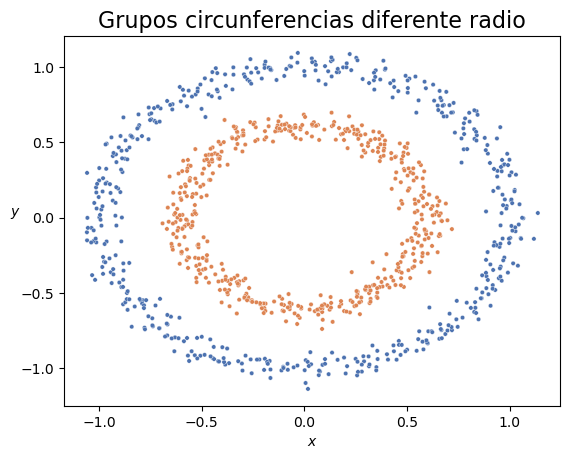

In [2]:
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.6)

# Primer scatter plot con las etiquetas originales
sns.scatterplot(x=[x_[0] for x_ in X], y=[x_[1] for x_ in X],
                hue=y,
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=10  # Tamaño de los puntos
                )
plt.title("Grupos circunferencias diferente radio", fontsize=16)
plt.xlabel("$x$", fontsize=10)
plt.ylabel("$y$", fontsize=10, rotation=0)
plt.show()

Dentro del módulo `cluster` de `sklearn` tenemos la clase **DBSCAN** *Density-Based Spatial Clustering of Applications with Noise*  que es un algoritmo de clustering basado en densidad que usa dos parámetros clave para detectar clusters de diferentes formas y tamaños.  

* *eps* (Épsilon): Es el radio máximo en el que DBSCAN buscará vecinos alrededor de un punto.
Determina qué puntos se consideran vecinos densos.

* *min_samples*: Es el mínimo número de puntos que deben estar dentro del radio *eps* para que un punto sea un núcleo de cluster.
Si un punto tiene al menos *min_samples* vecinos en su radio *eps*, se convierte en un punto central del cluster.

*  *metric*: Define la métrica de distancia usada. Por defecto usa `'euclidean'`, pero puedes usar Manhattan, coseno, etc.

* *algorithm*: Especifica el algoritmo usado para encontrar vecinos dentro de *eps*. Igual que en **K-NN**
    * `'auto'` elige el mejor
    * `'ball_tree'` eficiente en dimensiones bajas
    * `'kd_tree'` eficiente con datos estructurados
    * `'brute'` búsqueda directa, mejor si los datos son pequeños

In [3]:
dbscan = DBSCAN(eps=0.05, min_samples=5)

### Métodos y Atributos en DBSCAN

* `fit(X)`: Ajusta el modelo DBSCAN a los datos sin devolver valores.
Calcula los clusters y asigna etiquetas a los puntos.

* `fit_predict(X)`: Ajusta el modelo y devuelve las etiquetas de cluster directamente.

* `get_params(deep=True)`: Devuelve un diccionario con los parámetros del modelo DBSCAN.

* `dbscan.labels_`: No es un método sino un atributo. Devuelve las etiquetas asignadas a cada punto (-1 si es ruido).




In [4]:
dbscan.fit(X)
dbscan.labels_[0:100]

array([ 0, -1,  1,  2,  0, -1, 25, 41,  3,  4, -1,  5, -1,  0,  6,  5, 42,
       14,  7, 30, 20,  0, 12, -1,  8, -1,  5,  4,  9, 17, 22,  0, 10, -1,
        0,  0, -1, 11,  0, -1, 12,  9,  4, 13, 33, 13, 11,  5,  1, 35,  0,
       -1, -1,  0, 25,  0, 43,  0, 14, -1, -1, -1, 12, 12, -1,  0,  4,  5,
       -1,  3,  0, 15,  0, 16, 17, -1, 19, -1,  0,  5,  0, 15, -1, -1,  3,
       36, 10, -1, 18, -1, 44,  0, 19, 15,  2, -1, 20, 21,  0,  5],
      dtype=int64)

Generamos una máscara para identificar los puntos *aislados* etiquetados como ruido.

In [5]:
core_mask = dbscan.labels_ != -1
outlier_mask = dbscan.labels_ == -1

#### Representación gráfica

<Axes: >

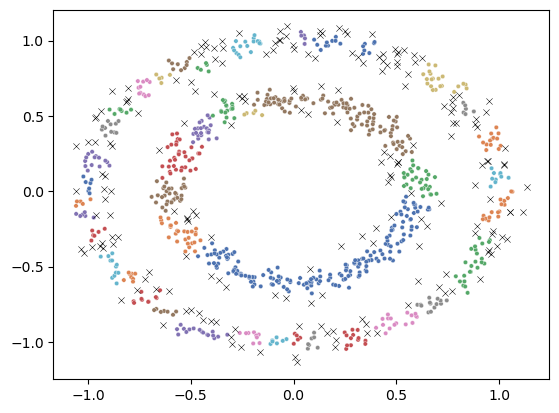

In [6]:
# Segundo scatter plot con las etiquetas predichas por DBSCAN
sns.scatterplot(x=[x_[0] for x_ in X[core_mask]], y=[x_[1] for x_ in X[core_mask]],
                hue=dbscan.labels_[core_mask],
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=10  # Tamaño de los puntos
                )
sns.scatterplot(x=[x_[0] for x_ in X[outlier_mask]], y=[x_[1] for x_ in X[outlier_mask]],
                color='k',  # Color diferente para los outliers
                marker="x",  # Marcador diferente para los outliers
                legend=None,
                s=20 
                )

In [7]:
print("Numero de nodos centrales: ",len(dbscan.core_sample_indices_))
print("Indices de los nodos centrales: ",dbscan.core_sample_indices_[:10])
print("Posición de los nodos centrales: ",dbscan.components_[:3])

Numero de nodos centrales:  566
Indices de los nodos centrales:  [ 0  2  3  4  8  9 11 13 14 15]
Posición de los nodos centrales:  [[ 0.52867266 -0.23997866]
 [ 0.92454503 -0.16252339]
 [-0.3332071   0.60031881]]


<Axes: >

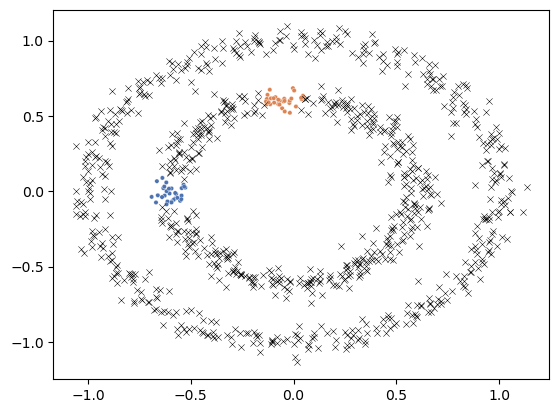

In [8]:
dbscan = DBSCAN(eps=0.10, min_samples=30)
dbscan.fit(X)

core_mask = dbscan.labels_ != -1
outlier_mask = dbscan.labels_ == -1

# Segundo scatter plot con las etiquetas predichas por DBSCAN
sns.scatterplot(x=[x_[0] for x_ in X[core_mask]], y=[x_[1] for x_ in X[core_mask]],
                hue=dbscan.labels_[core_mask],
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=10  # Tamaño de los puntos
                )
sns.scatterplot(x=[x_[0] for x_ in X[outlier_mask]], y=[x_[1] for x_ in X[outlier_mask]],
                color='k',  # Color diferente para los outliers
                marker="x",  # Marcador diferente para los outliers
                legend=None,
                s=20 
                )

## Escalado de datos

DBSCAN usa distancias (como Euclidiana o Manhattan) para encontrar clusters, y si las características tienen diferentes escalas, una dimensión puede dominar sobre las otras.


*  *Estandarización* (StandardScaler): Convierte los datos a una distribución con media 0 y desviación estándar 1. Útil si los datos tienen una distribución normal.

* *Normalización* (MinMaxScaler): Escala los valores entre 0 y 1.
Recomendado si los datos tienen valores en diferentes rangos.

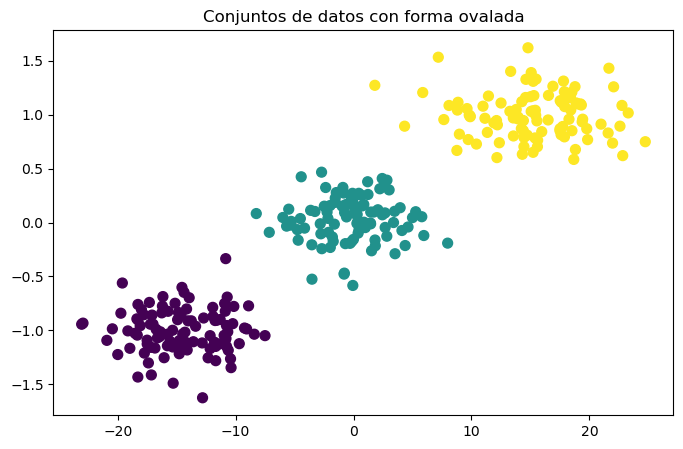

In [9]:

# Parámetros para los blobs
centros = [(-15, -1), (0, 0), (15, 1)]
n_samples = 300  # Número total de muestras
cluster_std = [(3.4, 0.2), (3.2, 0.2), (4.2, 0.2)]  # Desviaciones estándar en x y en y

# Crear blobs
X, y = make_blobs(n_samples=n_samples, centers=centros, cluster_std=[std for std in cluster_std], random_state=532)

plt.figure(figsize=(8, 5))
# Graficar los datos
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title('Conjuntos de datos con forma ovalada')
plt.show() 

<Axes: >

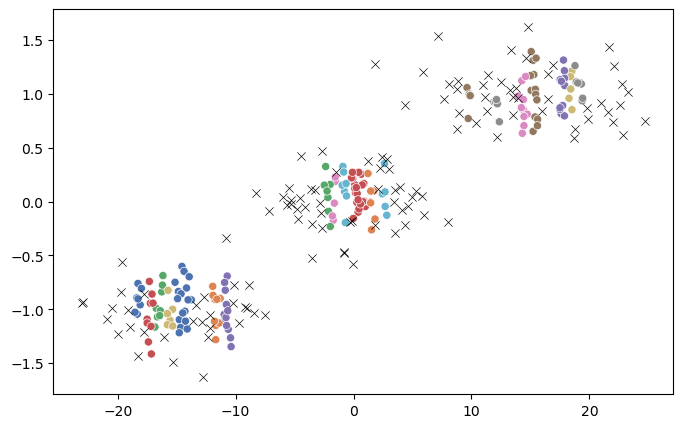

In [10]:
dbscan = DBSCAN(eps=0.30, min_samples=5)
dbscan.fit(X)

core_mask = dbscan.labels_ != -1
outlier_mask = dbscan.labels_ == -1

plt.figure(figsize=(8, 5))
# Segundo scatter plot con las etiquetas predichas por DBSCAN
sns.scatterplot(x=[x_[0] for x_ in X[core_mask]], y=[x_[1] for x_ in X[core_mask]],
                hue=dbscan.labels_[core_mask],
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=35  # Tamaño de los puntos
                )
sns.scatterplot(x=[x_[0] for x_ in X[outlier_mask]], y=[x_[1] for x_ in X[outlier_mask]],
                color='k',  # Color diferente para los outliers
                marker="x",  # Marcador diferente para los outliers
                legend=None,
                s=35 
                )

<Axes: >

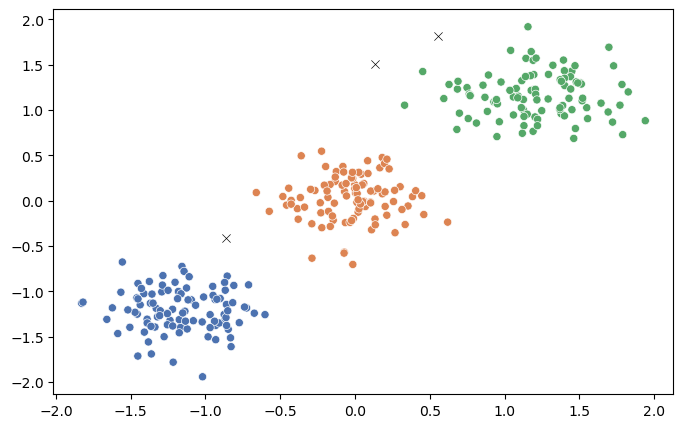

In [11]:
X = StandardScaler().fit_transform(X)
dbscan = DBSCAN(eps=0.30, min_samples=5)
dbscan.fit(X)

core_mask = dbscan.labels_ != -1
outlier_mask = dbscan.labels_ == -1

plt.figure(figsize=(8, 5))
# Segundo scatter plot con las etiquetas predichas por DBSCAN
sns.scatterplot(x=[x_[0] for x_ in X[core_mask]], y=[x_[1] for x_ in X[core_mask]],
                hue=dbscan.labels_[core_mask],
                palette="deep",
                marker="o",  # Marcador para etiquetas originales
                legend=None,
                s=35  # Tamaño de los puntos
                )
sns.scatterplot(x=[x_[0] for x_ in X[outlier_mask]], y=[x_[1] for x_ in X[outlier_mask]],
                color='k',  # Color diferente para los outliers
                marker="x",  # Marcador diferente para los outliers
                legend=None,
                s=35 
                )